# Podłużne ryzyko readmisji w programie opieki koordynowanej z PROC GEE

## Streszczenie

Ten notebook dopasowuje marginalny (uśredniony w populacji) model logistyczny dla **binarnego wyniku readmisji w ciągu 30 dni**, mierzonego wielokrotnie w czterech wizytach kontrolnych na pacjenta, wykorzystując **PROC GEE** do uwzględnienia korelacji wewnątrz pacjenta. Na zbilansowanej syntetycznej kohorcie **25 pacjentów obserwowanych przez 4 wizyty każdy (100 rekordów pacjent-wizyta)** model szacuje uśredniony w populacji efekt **programu opieki koordynowanej (Care-Management)** względem opieki standardowej, kontrolując płeć, wiek, obciążenie chorobami współistniejącymi i wizytę.

Dopasowanie z wymienną (exchangeable) strukturą korelacji zwraca współczynnik `factor(program)Standard` równy **+2,306** w skali logitowej z empirycznym (sandwich) błędem standardowym **0,467** (Z = 4,94, p < 0,0001): pacjenci w opiece standardowej mają wyraźnie wyższe szanse readmisji niż pacjenci w programie opieki koordynowanej. Eksponencjacja kontrastu daje **iloraz szans opieka koordynowana-vs-standardowa równy 0,10 (95% CI Walda 0,040 do 0,249)** — silny, statystycznie istotny efekt ochronny, którego przedział ufności nie obejmuje 1. Struktura AR(1) odtwarza ten sam współczynnik (**+2,315**), a struktura wymienna dopasowuje się lepiej według kryterium QIC (**111,77** vs **123,94**), więc wniosek nie jest artefaktem przyjętej struktury korelacji.

## Źródła danych

Wszystkie dane są generowane wewnętrznie przez pierwszy krok DATA (bez plików zewnętrznych, ustalone ziarno `101`). Jedna syntetyczna kohorta, `readmit`, zawiera **25 pacjentów obserwowanych każdy przez 4 wizyty (100 wierszy pacjent-wizyta)** — zbilansowany podłużny układ dopasowany do limitu 100 obserwacji tego środowiska, z `patient` jako jednostką grupowania.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `patient` | num | ID pacjenta — jednostka grupowania/podmiot dla powtarzanych pomiarów |
| `visit` | num | Numer wizyty kontrolnej (1-4), indeks czasowy wewnątrz podmiotu |
| `program` | char | Program opieki: `CareMgmt` (interwencja) lub `Standard` |
| `sex` | char | Płeć pacjenta (`Female`/`Male`) |
| `age` | num | Wiek w latach (~50-70) |
| `age_c` | num | Wiek wyśrodkowany/przeskalowany, `(age-60)/10`, kowariata modelu |
| `comorbid` | num | Liczba chorób współistniejących (Poisson, średnia ~2) |
| `readmit` | num | Wynik binarny: 1 = readmisja w ciągu 30 dni od wizyty, w przeciwnym razie 0 |

Model generujący dane zawiera prawdziwy efekt ochronny programu (log-szanse **-1,4** dla `CareMgmt`), rosnące ryzyko wraz z chorobami współistniejącymi i wiekiem, łagodny malejący trend wizyt oraz losowy efekt na poziomie pacjenta (`u`, SD 1,1), dzięki czemu powtarzane obserwacje tego samego pacjenta są dodatnio skorelowane — dokładnie taką strukturę PROC GEE ma obsługiwać. Pacjenci są przypisywani do dwóch programów naprzemiennie, aby ramiona były zbilansowane (13 opieka koordynowana, 12 standardowa).

## Dlaczego model marginalny dla tego pytania

Szpitale są coraz częściej rozliczane z **readmisji w ciągu 30 dni**. Częste pytanie ewaluacyjne brzmi: *czy zapisanie wypisanych pacjentów do programu opieki koordynowanej obniża ich ryzyko readmisji?* Ponieważ każdy pacjent jest obserwowany w kilku wizytach po wypisie, powtarzane wyniki binarne u jednego pacjenta są **skorelowane**, co narusza założenie niezależności zwykłej regresji logistycznej i zaniża jej błędy standardowe.

**PROC GEE** (uogólnione równania szacujące) dopasowuje *marginalny*, uśredniony w populacji model logistyczny i koryguje błędy standardowe ze względu na korelację wewnątrz pacjenta, wykorzystując roboczą macierz korelacji oraz empiryczny (sandwich) estymator wariancji. Współczynniki regresji opisują efekt kowariaty **uśredniony po populacji** — naturalny cel dla pytania o ewaluację programu.

Ten notebook:
1. Symuluje zbilansowaną podłużną kohortę mieszczącą się w limicie 100 obserwacji.
2. Dopasowuje marginalny logistyczny model GEE z wymienną roboczą strukturą korelacji.
3. Przekłada współczynnik programu na iloraz szans z przedziałem ufności Walda.
4. Porównuje dopasowanie ze strukturą AR(1) (wizyty są uporządkowane w czasie) za pomocą QIC.

## Krok 1 — Symulacja podłużnej kohorty

Generujemy **25 pacjentów, każdy obserwowany przez 4 wizyty (100 wierszy)**. Losowy efekt na poziomie pacjenta `u` wywołuje dodatnią korelację wewnątrz pacjenta, którą PROC GEE musi uwzględnić; predyktor liniowy w skali logitowej koduje ochronny efekt programu opieki koordynowanej (-1,4), rosnące ryzyko wraz z chorobami współistniejącymi i wiekiem oraz łagodny trend malejący wraz z wizytami. Pacjenci są naprzemiennie przypisywani do dwóch programów, aby ramiona były zbilansowane. `call streaminit` ustala ziarno dla powtarzalności.

In [1]:
DANE readmit;
   CALL streaminit(101);
   DŁUGOŚĆ program $9 sex $6;
   POWTÓRZ patient = 1 TO 25;
      /* Naprzemienne przypisanie utrzymuje rownowage obu ramion */
      JEŚLI mod(patient, 2) = 1 WTEDY program = "CareMgmt";
      PRZECIWNIE program = "Standard";
      JEŚLI rand("uniform") < 0.5 WTEDY sex = "Female";
      PRZECIWNIE sex = "Male";
      AGE = round(50 + 20*rand("uniform"));
      comorbid = rand("poisson", 2.0);
      /* Losowy efekt na poziomie pacjenta -> korelacja wewnatrz pacjenta */
      u = rand("normal", 0, 1.1);
      POWTÓRZ visit = 1 TO 4;
         age_c = (AGE - 60)/10;
         eta = 0.1
               + (program = "CareMgmt")*(-1.4)
               + 0.40*comorbid
               + 0.25*age_c
               - 0.15*visit
               + u;
         p = 1/(1 + EXP(-eta));
         readmit = (rand("uniform") < p);
         WYJŚCIE;
      KONIEC;
   KONIEC;
   USUŃ u eta p;
WYKONAJ;


NOTE: DATA readmit


NOTE: Wrote readmit (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 — Inspekcja kohorty

Szybka częstość wyniku według programu potwierdza, że dane wyglądają sensownie przed modelowaniem, a `PROC MEANS` podsumowuje ciągłe kowarianty. Tabela krzyżowa już zapowiada duży efekt programu: pacjenci w programie opieki koordynowanej są readmitowani znacznie rzadziej niż pacjenci opieki standardowej.

                                                   The FREQ Procedure

Table of Program opieki by Ponowna hospitalizacja

Program opieki |         0 |         1 |      Total
---------------+-----------+-----------+-----------
CareMgmt       |        36 |        16 |         52
---------------+-----------+-----------+-----------
Standard       |        11 |        37 |         48
---------------+-----------+-----------+-----------
Total          |        47 |        53 |        100

                                                  The MEANS Procedure

 Variable  Label                                   N           Mean        Std Dev        Minimum        Maximum
 ---------------------------------------------------------------------------------------------------------------
 AGE       Wiek                                  100     60.7600000      5.5215281     52.0000000     69.0000000
 comorbid  Liczba chorob wspolistniejacych       100      2.0800000      1.5287150      0.0000000      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_program_readmit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


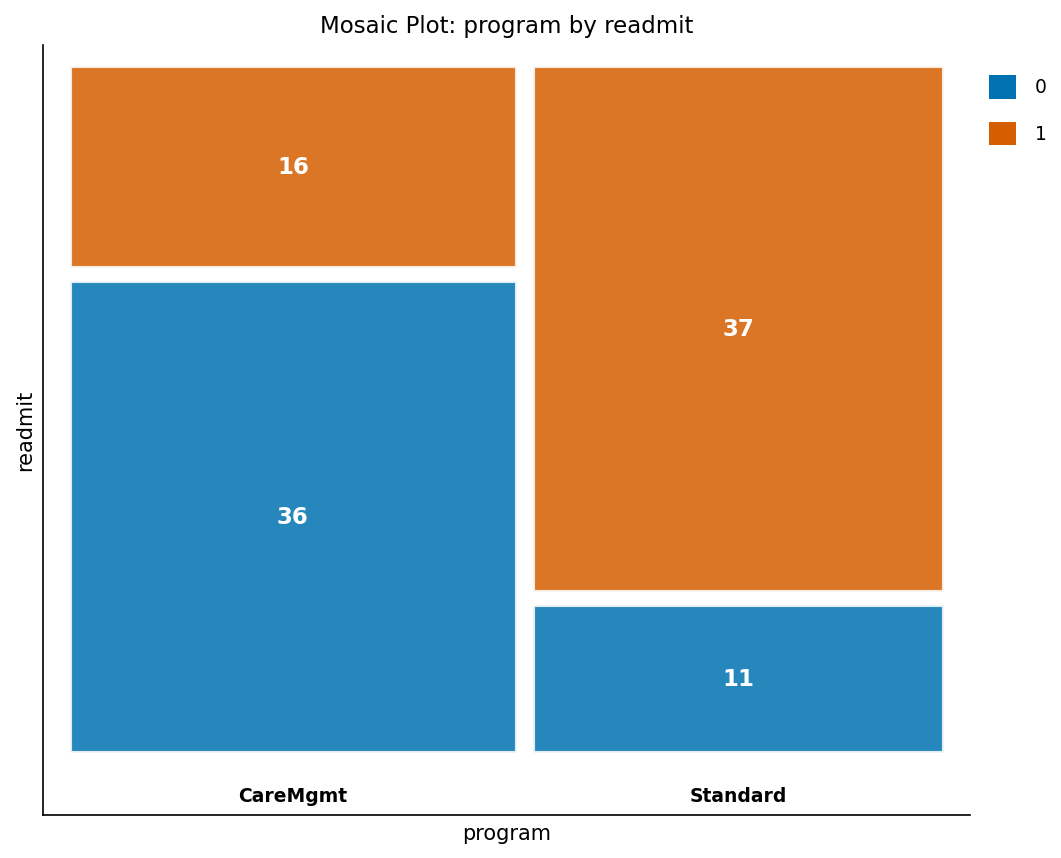

In [2]:
PROCEDURA CZĘSTOŚCI DANE=readmit;
   TABLES program*readmit / nocol nopercent;
   ETYKIETA program="Program opieki" readmit="Ponowna hospitalizacja";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=readmit n mean std MIN MAX;
   ZMIENNA AGE comorbid visit readmit;
   ETYKIETA AGE="Wiek" comorbid="Liczba chorob wspolistniejacych" visit="Wizyta"
         readmit="Ponowna hospitalizacja";
WYKONAJ;

## Krok 3 — Marginalny logistyczny GEE (wymienna robocza struktura korelacji)

Instrukcja `REPEATED SUBJECT=patient` deklaruje, że obserwacje należące do tego samego `patient` są skorelowane. `CORR=EXCH` zakłada, że każda para wizyt w obrębie pacjenta ma taką samą korelację — sensowna wartość domyślna dla powtarzanych pomiarów bez silnego uporządkowania czasowego. `CORRW` raportuje oszacowany parametr roboczej korelacji. Instrukcja `CLASS` wprowadza `program` i `sex` jako efekty kategorialne; procedura używa `CareMgmt` jako poziomu odniesienia, więc raportowany współczynnik `factor(program)Standard` to zmiana log-szans dla **opieki standardowej względem opieki koordynowanej**.

PROC GEE raportuje **oba** rodzaje błędów standardowych — empiryczne (sandwich) i oparte na modelu; to błędy empiryczne są tymi, którym należy ufać, ponieważ pozostają poprawne nawet gdy robocza struktura korelacji jest błędnie określona.

In [3]:
PROCEDURA gee DANE=readmit;
   KLASA program(REF="Standard") sex;
   MODEL readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=exch CORRW;
   ETYKIETA program="Program opieki" sex="Plec" age_c="Wiek (standaryzowany)"
         comorbid="Liczba chorob wspolistniejacych" visit="Wizyta"
         readmit="Ponowna hospitalizacja";
WYKONAJ;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Ponowna hospitalizacja
Distribution: binomial
Link Function: logit
Working Correlation Structure: exchangeable
Correlation Type: Compound Symmetry
Number of Observations Read: 100
Number of Clusters: 25
QIC = 111.768066
QICu = 120.784355

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.572142     0.781673    -2.0113     0.0443
factor(program)Standard              2.306431     0.466895     4.9399     0.0000
factor(sex)Male                      0.688293     0.617224     1.1151     0.2648
Wiek (standaryzowany)                0.763003     0.464270     1.6434     0.1003
Liczba chorob wspolistniejacych      0.273238     0.2


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Exchangeable)

NOTE: PROC GEE wrapper=python


## Krok 4 — Efekt programu jako iloraz szans

Współczynniki modelu są w skali logitowej. Aby przekazać efekt programu interesariuszom klinicznym, potrzebujemy **ilorazu szans**. Bierzemy empiryczne oszacowanie `factor(program)Standard` (**2,306431**) i jego empiryczny błąd standardowy (**0,466895**) z dopasowania wymiennego powyżej i eksponencjujemy je w krótkim kroku DATA: `exp(beta)` to iloraz szans standardowa-vs-opieka koordynowana, a ochronny iloraz szans opieka koordynowana-vs-standardowa to jego odwrotność. 95% przedział ufności Walda pochodzi z `exp(beta +/- 1,96 * SE)`. To przekształca współczynnik regresji w marginalny iloraz szans raportowany płatnikowi lub zespołowi ds. jakości.

In [4]:
DANE program_or;
   /* Empiryczne (sandwich) oszacowanie dla standardowej vs opieki koordynowanej
      z wymiennego dopasowania GEE z Kroku 3 (CareMgmt jest poziomem odniesienia). */
   beta = 2.306431;
   se   = 0.466895;
   z    = 1.959964;   /* 97.5 percentyl standardowego rozkladu normalnego */

   /* Opieka standardowa wzgledem opieki koordynowanej */
   or_standard_vs_care = EXP(beta);
   lcl_standard        = EXP(beta - z*se);
   ucl_standard        = EXP(beta + z*se);

   /* Ochronny efekt opieki koordynowanej = kontrast odwrotny */
   or_care_vs_standard = EXP(-beta);
   lcl_care            = EXP(-beta - z*se);
   ucl_care            = EXP(-beta + z*se);

   format or_standard_vs_care lcl_standard ucl_standard
          or_care_vs_standard lcl_care ucl_care 8.3;
WYKONAJ;

PROCEDURA DRUKUJ DANE=program_or noobs;
   ZMIENNA or_standard_vs_care lcl_standard ucl_standard
       or_care_vs_standard lcl_care ucl_care;
   ETYKIETA or_standard_vs_care="IS standardowa-vs-opieka"
         lcl_standard="Dolny CI (standardowa)"
         ucl_standard="Gorny CI (standardowa)"
         or_care_vs_standard="IS opieka-vs-standardowa"
         lcl_care="Dolny CI (opieka)"
         ucl_care="Gorny CI (opieka)";
WYKONAJ;


IS standardowa-vs-opieka  Dolny CI (standardowa)  Gorny CI (standardowa)  IS opieka-vs-standardowa  Dolny CI (opieka)  Gorny CI (opieka)
------------------------  ----------------------  ----------------------  ------------------------  -----------------  -----------------
                  10.039                   4.020                  25.066                     0.100              0.040              0.249




NOTE: DATA program_or


NOTE: Wrote program_or (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=program_or

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


## Krok 5 — Wrażliwość na strukturę korelacji (AR(1))

Ponieważ wizyty są uporządkowane w czasie, korelacja między wizytami może zanikać wraz z odstępem czasowym. Dopasowujemy ponownie z **autoregresyjną pierwszego rzędu** roboczą strukturą korelacji, `CORR=AR(1)`. Współczynniki GEE powinny być stabilne wobec rozsądnych wyborów korelacji; duże przesunięcia sygnalizowałyby wrażliwość wartą zbadania. Porównanie kryterium dopasowania QIC między strukturami pomaga wybrać lepiej dopasowaną roboczą korelację.

In [5]:
PROCEDURA gee DANE=readmit;
   KLASA program(REF="Standard") sex;
   MODEL readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=ar(1) CORRW;
   ETYKIETA program="Program opieki" sex="Plec" age_c="Wiek (standaryzowany)"
         comorbid="Liczba chorob wspolistniejacych" visit="Wizyta"
         readmit="Ponowna hospitalizacja";
WYKONAJ;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Ponowna hospitalizacja
Distribution: binomial
Link Function: logit
Working Correlation Structure: ar1
Correlation Type: First-Order Autoregressive
Number of Observations Read: 100
Number of Clusters: 25
QIC = 123.944817
QICu = 120.792514

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.585344     0.777886    -2.0380     0.0415
factor(program)Standard              2.314720     0.466627     4.9605     0.0000
factor(sex)Male                      0.714028     0.613258     1.1643     0.2443
Wiek (standaryzowany)                0.795159     0.464005     1.7137     0.0866
Liczba chorob wspolistniejacych      0.266728     0.2


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Ar1)

NOTE: PROC GEE wrapper=r


## Interpretacja wyników

- **Korelacja wewnątrz pacjenta jest dodatnia.** Wymienny parametr roboczej korelacji wynosi **alpha = 0,058** (AR(1): **0,095**), co potwierdza, że powtarzane wyniki readmisji u tego samego pacjenta poruszają się razem. Zignorowanie tego (zwykła regresja logistyczna) zaniżyłoby błędy standardowe i zawyżyło istotność.
- **Błąd empiryczny vs. oparty na modelu.** PROC GEE raportuje oba; wnioskowanie tutaj opiera się na błędach **empirycznych (sandwich)**, które pozostają poprawne nawet gdy robocza korelacja jest błędnie określona. Dla efektu programu błąd empiryczny wynosi **0,467** wobec **0,566** opartego na modelu.
- **Efekt programu.** Współczynnik `factor(program)Standard` wynosi **+2,306** (Z = 4,94, p < 0,0001): pacjenci opieki standardowej mają istotnie wyższe uśrednione w populacji szanse readmisji w ciągu 30 dni niż pacjenci programu opieki koordynowanej. Krok 4 przekłada to na **iloraz szans opieka koordynowana-vs-standardowa równy 0,10 (95% CI Walda 0,040 do 0,249)** — duży efekt ochronny, którego przedział nie obejmuje 1, więc jest statystycznie odróżnialny od braku efektu. Surowa tabela krzyżowa potwierdza: **31% wizyt pacjentów opieki koordynowanej zakończyło się readmisją (16/52) wobec 77% w opiece standardowej (37/48)**.
- **Inne czynniki.** Wiek (współczynnik +0,76) i liczba chorób współistniejących (+0,27) zwiększają szanse readmisji, natomiast ryzyko lekko maleje wraz z kolejnymi wizytami (-0,07) — zgodnie z mechanizmem generującym dane, choć tylko efekt programu jest indywidualnie istotny przy tej wielkości próby.
- **Wybór struktury.** Dopasowania wymienne i AR(1) dają niemal identyczne współczynniki programu (**+2,306** vs **+2,315**), więc wnioski o efekcie programu nie są artefaktem przyjętej korelacji. Struktura wymienna ma niższe **QIC (111,77 vs 123,94)**, więc jest tu lepiej dopasowaną roboczą korelacją.

**Wniosek końcowy:** PROC GEE dostarcza obronny, uśredniony w populacji szacunek efektu programu opieki na skorelowany wynik binarny — dokładnie taką marginalną interpretację, jakiej potrzebuje płatnik lub zespół poprawy jakości, z błędami standardowymi respektującymi układ powtarzanych pomiarów.